In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Biblioteca Pandas, series y dataframes

Pandas es una biblioteca de Python muy usada para análisis y manipulación de datos. Provee principalmente dos tipos de clases para trabajar con datos:

- **Series:** un vector unidimensional indexado, que contiene datos de cualquier tipo
como números enteros, cadenas, objetos Python, etc.

- **DataFrame:** una estructura de datos bidimensional que contiene datos como una matriz bidimensional o una tabla con filas y columnas.

Bibliografía recomendada: Sección 5 de Python for Data Analysis, de Wes McKinney (creador de la biblioteca Pandas), disponible on-line en forma gratuita en la página
https://wesmckinney.com/book/pandas-basics

### Series

Las series de Pandas son vectores similares a los arrays de NumPy, que podemos indexar usando etiquetas.

Crear la siguiente Series, observar qué devuelve `values` e `index` e interpretar.

In [ ]:
import pandas as pd
enteros = pd.Series([7,4,-5,3])
enteros

In [ ]:
enteros.values

In [ ]:
enteros.index # Por default, los índices van de 0 a N-1.

Podemos asignar etiquetas (o índices) a cada valor de la serie.

In [ ]:
reales = pd.Series([np.pi,0,-2,1.41], index = ["a", "b", "c", "d"])
display(reales)

In [ ]:
display(reales.values)
display(reales.index)

Para acceder a los elementos podemos usar las etiquetas.

In [ ]:
print(reales["a"])

In [ ]:
reales = pd.Series([np.pi,0,-2,1.41], index = ["a", "b", "c", "d"])
display(reales)

In [ ]:
# Acceder por su posición no está recomendado. 
reales[1]

In [ ]:
# Para acceder por su posición usamos iloc
reales.iloc[1]

In [ ]:
# Podemos usar también rangos
reales.iloc[1:3]

In [ ]:
# Para acceder por etiquetas podemos usar también loc
reales.loc["a":"c"]

In [ ]:
# Podemos definir labels numericos
temperaturas = pd.Series([15, 17, 18.2, 25], index = np.array([5, 10, 15, 20]))
print(temperaturas)

In [ ]:
# Que esperamos de los siguientes comandos?
print(temperaturas.iloc[1:3])
print(temperaturas.loc[10:20]) # Por qué??

In [ ]:
# Funcionará?
temperaturas.iloc[10]

In [ ]:
# Podemos seleccionar elementos mediante una lista de etiquetas
realesSub = reales[["a","b"]]
print(realesSub)
print(realesSub.index)

## Operaciones con series
Las operaciones que pueden aplicarse a numpy arrays pueden aplicarse también a series de Pandas, conservando los índices.

In [ ]:
reales

In [ ]:
np.exp(reales)

In [ ]:
reales * 3

In [ ]:
reales > 1

In [ ]:
reales[reales > 1]

¿Qué esperamos que dé este código?

In [ ]:
print(enteros)
print(reales)

In [ ]:
enteros + reales

NaN significa "not a number", se utiliza en series de Pandas para valores faltantes (missing values).

In [ ]:
# Y ahora?
enteros2 = pd.Series([1,2,3,4], index = ["d", "b", "y", "z"])
enteros2

In [ ]:
reales + enteros2

Vemos que solo se suman las filas con índices iguales.

Las series de Pandas tienen varias funciones útiles que iremos viendo más adelante. A modo de ejemplo, interpretar que hacen las siguientes funciones.

In [ ]:
series1 = pd.Series(["a", "b", "c", "b", "a", "c", "x"])
series1

In [ ]:
series1.isin(["b", "c"])

In [ ]:
# Pregunta: cómo me quedo solo con las filas con letras "b" o "c"?


In [ ]:
# Qué hace este método?
series1.value_counts()

### DataFrames
Un data frame es una representación de los datos en formato de tabla en la que cada
columna son vectores del mismo tamaño. Como cada columna es un vector, cada columna puede
contener datos de un único tipo. Se pueden pensar como variables. Cada variable corresponde a una
serie de Pandas, y **todas las series de un dataframe están indexadas por los mismos índices**.

Una forma de crear un data frame es utilizando un "diccionario". Todas las variables del
diccionario deben ser vectores o listas de la misma longitud. 

In [ ]:
data = {"nombres": ["Rodrigo", "Sergio", "Cristina", "Diana"], "altura": np.array([178, 172, 175, 168]), "peso": np.array
([81.2, 76.1, 68.5, 64.0])}
display(data)

In [ ]:
type(data)

In [ ]:
data["peso"]

In [ ]:
# Creamos un data frame con esos datos. Cuáles son los índices?
pacientes = pd.DataFrame(data)
pacientes

In [ ]:
# En este ejemplo podemos usar los nombres como índices
pacientes = pd.DataFrame(data).set_index("nombres")
display(pacientes)

In [ ]:
# Podemos acceder a las columnas de dos formas distintas
alturas = pacientes["altura"]
alturas

In [ ]:
pacientes.altura

In [ ]:
type(alturas)

In [ ]:
alturas.dtype

A diferencia de las matrices en Numpy, un DataFrame de Pandas es un conjunto de columnas, no de filas. 
Si queremos saber la altura de Rodrigo, pensar cuál de los dos comandos será correcto antes de ejecutarlos.

In [ ]:
pacientes["Rodrigo"].altura

In [ ]:
pacientes["altura"].Rodrigo

Para acceder a una fila de un dataframe, podemos usar los métodos `loc[]` y `iloc[]`. 

¿Cómo se usan? ¿Cuál es la diferencia entre los dos comandos? ¿Que tipo de dato nos devuelve?

## Archivos de datos

La biblioteca Pandas nos permite trabajar fácilmente con archivos de datos.
1. Leer el archivo casos_coronavirus.csv .
2. Graficar la curva de casos por día.
3. Graficar la curva de casos acumulados.
4. Definir log_cum_casos como el logaritmo de la cantidad de casos acumulados y graficar en función de la cantidad de días transcurridos.
5. Estimar, tomando dos valores, la pendiente de la recta para los datos a partir del dia 30.
6. Graficar la recta estimada junto con los datos. ¿Consideran que es una buena estimación?


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("casos_coronavirus.csv") # DataFrame
df.head()  # Primeras filas del DataFrame

In [ ]:
# Información básica del DataFrame
df.info()

In [ ]:
# ¿Cómo usamos la fecha como índice?
df = pd.read_csv("casos_coronavirus.csv").set_index("fecha")
df

In [ ]:
# Graficamos utilizando el método plot de series de Pandas
df["confirmados_Nuevos"].plot()

In [ ]:
# Queremos graficar los casos acumulados, podemos usar el método cumsum() de series Pandas
df.confirmados_Nuevos.cumsum().plot()

**Ejercicio** 
Esta serie presenta un crecimiento exponencial. 
Queremos tomar logaritmos para linealizar, ¿como podemos hacerlo?


**Ejercicio**
Estimar la pendiente de la recta antes del confinamiento (dias 5 al 25) y la pendiente de la recta después del confinamiento.

In [ ]:
# Agregamos la recta
x_recta = ???
y_recta = ???
plt.plot(y)
plt.plot(x_recta, y_recta)


## Gapminder

A modo de ejemplo, vamos a explorar el dataset Gapminder que contiene datos poblacionales y de desarrollo humano de distintos países a lo largo del tiempo.

Si gapminder no está instalado, ejecutar el siguiente comando para instalarlo

In [3]:
%pip install gapminder

Note: you may need to restart the kernel to use updated packages.


In [4]:
from gapminder import gapminder

/home/carlos/miniconda3/envs/venv/lib/python3.12/site-packages/gapminder/data.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Si les da un error de proxy al instalar paquetes, utilicen estos comandos para eliminar la configuración de proxy:

In [ ]:
# Ejecutar si no funcionó lo de arriba
import os
for k in ["HTTP_PROXY","HTTPS_PROXY","http_proxy","https_proxy"]:
    os.environ.pop(k, None)

Si sigue sin funcionar, pueden descargar gapminder del sitio web:

In [5]:
# Ejecutar si no funcionó lo de arriba
url = "https://raw.githubusercontent.com/resbaz/r-novice-gapminder-files/master/data/gapminder-FiveYearData.csv"
gapminder = pd.read_csv(url)

In [6]:
# Verificamos si se cargo correctamente
display(gapminder)

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,1987,9216418.0,Africa,62.351,706.157306
1700,Zimbabwe,1992,10704340.0,Africa,60.377,693.420786
1701,Zimbabwe,1997,11404948.0,Africa,46.809,792.449960
1702,Zimbabwe,2002,11926563.0,Africa,39.989,672.038623


**Pregunta:** Podemos usar alguna columna como índice?

In [7]:
# Para ver las primeras cinco filas
gapminder.head()

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


Podemos ver información básica del DataFrame con la función info

In [8]:
gapminder.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   object 
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB


In [9]:
# Vemos todos los países en la base
gapminder["country"].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Australia', 'Austria', 'Bahrain', 'Bangladesh', 'Belgium',
       'Benin', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon',
       'Canada', 'Central African Republic', 'Chad', 'Chile', 'China',
       'Colombia', 'Comoros', 'Congo Dem. Rep.', 'Congo Rep.',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Czech Republic',
       'Denmark', 'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Ethiopia',
       'Finland', 'France', 'Gabon', 'Gambia', 'Germany', 'Ghana',
       'Greece', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Haiti',
       'Honduras', 'Hong Kong China', 'Hungary', 'Iceland', 'India',
       'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy',
       'Jamaica', 'Japan', 'Jordan', 'Kenya', 'Korea Dem. Rep.',
       'Korea Rep.', 'Kuwait', 'Lebanon',

In [10]:
# Cuántos países son?
gapminder["country"].nunique()

142

In [14]:
gapminder["country"].unique().size

142

### Entrada en calor

1. Cuál era la población de Argentina en 1967? Y la de Brasil?
2. En qué países la expectativa de vida era mayor que 80 años en 2002? Y en 1997? (filtrar la tabla para dejar solo las filas correspondientes)
   

In [34]:
# 1
gapminder[(gapminder["country"] == "Brazil") & (gapminder["year"] == 1967)]

,country,year,pop,continent,lifeExp,gdpPercap
171,Brazil,1967,88049823.0,Americas,57.632,3429.864357


In [33]:
# 2
gapminder[(gapminder["year"] == 2002) & (gapminder["lifeExp"] > 80)]

,country,year,pop,continent,lifeExp,gdpPercap
70,Australia,2002,19546792.0,Oceania,80.370,30687.75473
670,Hong Kong China,2002,6762476.0,Asia,81.495,30209.01516
694,Iceland,2002,288030.0,Europe,80.500,31163.20196
778,Italy,2002,57926999.0,Europe,80.240,27968.09817
802,Japan,2002,127065841.0,Asia,82.000,28604.59190
1474,Sweden,2002,8954175.0,Europe,80.040,29341.63093
1486,Switzerland,2002,7361757.0,Europe,80.620,34480.95771


### groupby

In [35]:
# Si queremos ver cuántos países hay en cada continente...
# podemos agregupar por continente y ver el tamaño de cada grupo
gapminder.groupby("continent").size()    # Para un dataframe agrupado, size es un método!

continent
Africa      624
Americas    300
Asia        396
Europe      360
Oceania      24
dtype: int64

In [36]:
# Pero cada país aparece varias veces, con datos de distintos años.
# Para contar sin repeticion usamos nuevamente nunique
cantidades = gapminder.groupby("continent")["country"].nunique()
cantidades

continent
Africa      52
Americas    25
Asia        33
Europe      30
Oceania      2
Name: country, dtype: int64

In [40]:
# Que tipo de dato nos devolvió? Cómo está indexado?
# Es una serie. Indexada por pais. Puedo filtrar usando ese index, pais
cantidades["Africa"]

np.int64(52)

In [41]:
type(cantidades["Africa"])

numpy.int64

In [42]:
# Si queremos calcular porcentajes, dividimos por la cantidad total de paises
totalPaises = gapminder["country"].nunique()
totalPaises
gapminder.groupby("continent")["country"].nunique() / totalPaises

continent
Africa      0.366197
Americas    0.176056
Asia        0.232394
Europe      0.211268
Oceania     0.014085
Name: country, dtype: float64

### value_counts

In [49]:
# O podemos usar el comando value_counts y pasarle un parámetro para que nos de los valores normalizados.
# (la normalización lleva la suma total a 1)
gapminder[["continent", "country"]].drop_duplicates().continent.value_counts(normalize=True)

# Tambien se puede usar (mantiene todas las otras columnas)
# gapminder.drop_duplicates(subset=["country", "continent"])

continent
Africa      0.366197
Asia        0.232394
Europe      0.211268
Americas    0.176056
Oceania     0.014085
Name: proportion, dtype: float64

In [50]:
# Vemos todos los años disponibles
gapminder["year"].unique()

array([1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002,
       2007])

In [51]:
# Tenemos datos de todos los países todos los años?
# Agrupamos los datos por año y calculamos el tamaño de cada bloque
gapminder.groupby("year").size()

year
1952    142
1957    142
1962    142
1967    142
1972    142
1977    142
1982    142
1987    142
1992    142
1997    142
2002    142
2007    142
dtype: int64

In [57]:
# Ejercicio: cómo podemos hacerlo utilizando value_counts?
gapminder["year"].value_counts()

year
1952    142
1957    142
1962    142
1967    142
1972    142
1977    142
1982    142
1987    142
1992    142
1997    142
2002    142
2007    142
Name: count, dtype: int64

In [66]:
# Ejercicio: cómo podemos calcular la poblacion total por año
gapminder.groupby("year")["pop"].sum()

year
1952    2.406957e+09
1957    2.664405e+09
1962    2.899783e+09
1967    3.217478e+09
1972    3.576977e+09
1977    3.930046e+09
1982    4.289437e+09
1987    4.691477e+09
1992    5.110710e+09
1997    5.515204e+09
2002    5.886978e+09
2007    6.251013e+09
Name: pop, dtype: float64

### Gráficos simples de funciones o puntos en el plano XY.
Vamos a graficar la población total mundial en función del año.

In [67]:
pobAnual = gapminder.groupby("year")["pop"].sum()
type(pobAnual)

pandas.core.series.Series

In [68]:
pobAnual

year
1952    2.406957e+09
1957    2.664405e+09
1962    2.899783e+09
1967    3.217478e+09
1972    3.576977e+09
1977    3.930046e+09
1982    4.289437e+09
1987    4.691477e+09
1992    5.110710e+09
1997    5.515204e+09
2002    5.886978e+09
2007    6.251013e+09
Name: pop, dtype: float64

In [69]:
pobAnual.index

Index([1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002, 2007], dtype='int64', name='year')

<Axes: xlabel='year'>

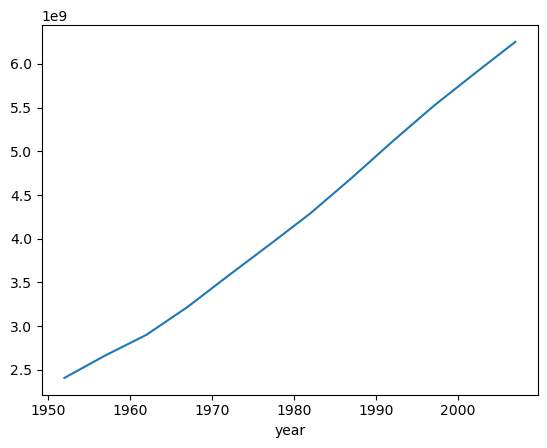

In [70]:
# Opción 1
# Usamos la función plot de series de pandas
pobAnual.plot()

<Axes: xlabel='year'>

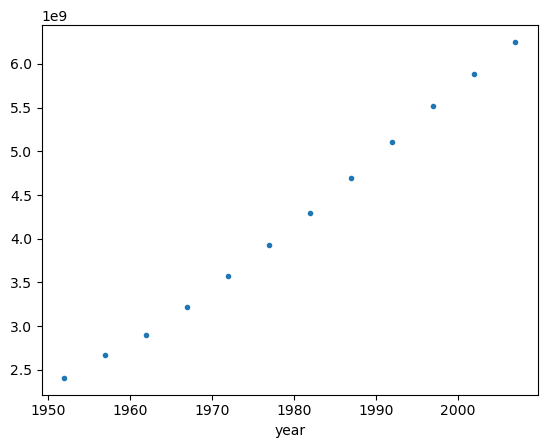

In [71]:
# O podemos graficar solo puntos
pobAnual.plot(style = ".")

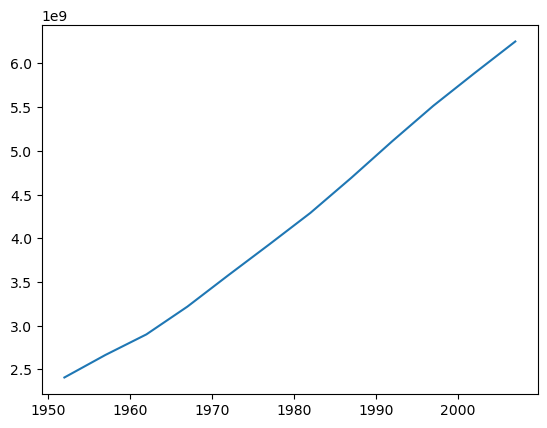

In [72]:
# Opcion 3
# Asignamos los valores a variables (arrays de numpy) y graficamos las variables
x = pobAnual.index
y = pobAnual.values
plt.plot(x,y)

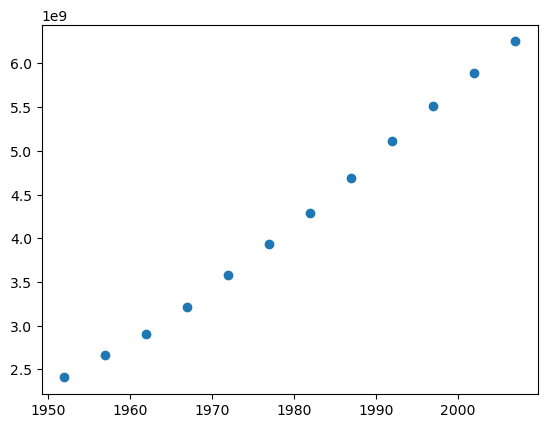

In [73]:
# Opcion 4
# Matplotlib tiene una función scatter para graficar puntos
plt.scatter(x,y)

In [74]:
# Vamos a analizar los datos de 2007
datos2007 = gapminder[gapminder["year"]==2007]

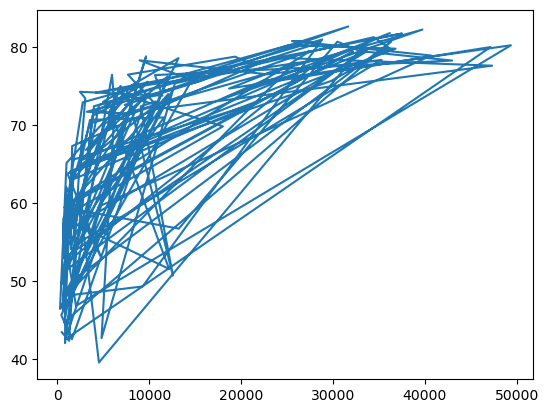

In [75]:
# Queremos ver si hay relación entre el producto bruto y la expectativa de vida
plt.plot(datos2007.gdpPercap, datos2007.lifeExp)

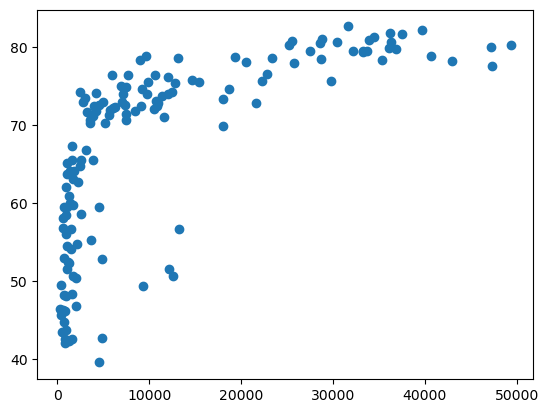

In [76]:
# Ay no, eso no, hacemos un "scatter plot"
plt.scatter(datos2007.gdpPercap, datos2007.lifeExp)
plt.show()

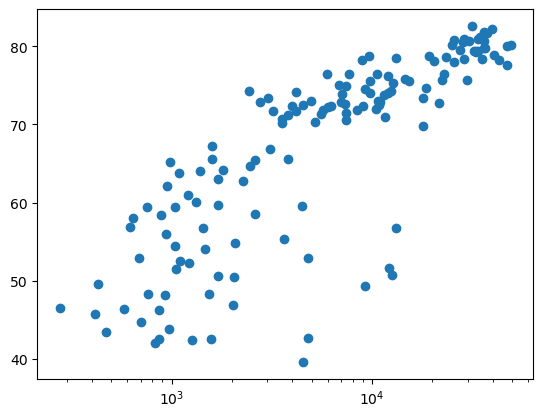

In [77]:
# Se ve mejor la correlación si usamos escala logaritmica en el eje X
plt.scatter(datos2007.gdpPercap, datos2007.lifeExp)
plt.xscale('log')

Vamos a mejorar un poco el gráfico

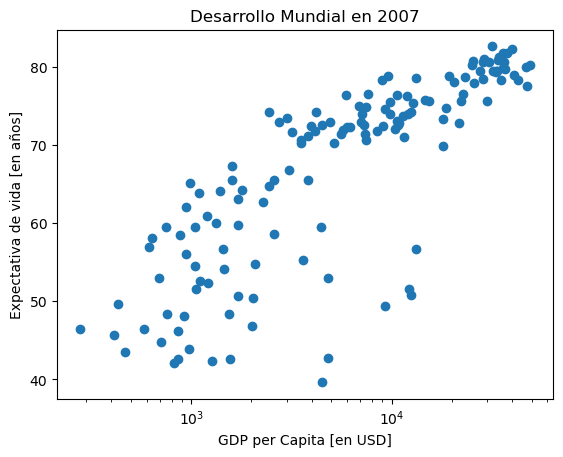

In [78]:
# Agregamos etiquetas al gráfico y a los ejes
plt.scatter(datos2007.gdpPercap, datos2007.lifeExp)
plt.xscale('log')
plt.xlabel('GDP per Capita [en USD]')
plt.ylabel('Expectativa de vida [en años]')
plt.title('Desarrollo Mundial en 2007')
plt.show()

Reemplacemos las marcas en el eje $x$ 10³, 10⁴, 10⁵ con 1k, 10k y 100k. 

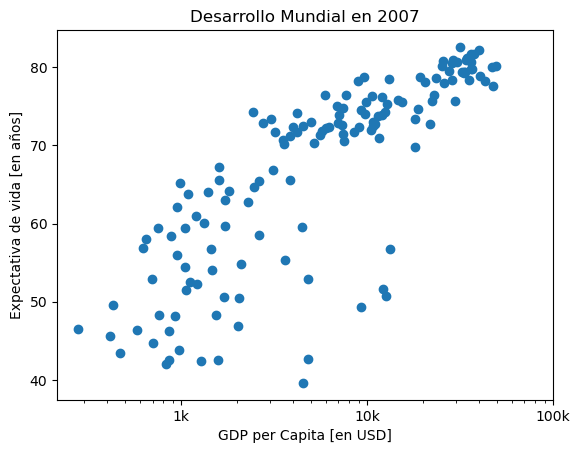

In [79]:
plt.scatter(datos2007.gdpPercap, datos2007.lifeExp)
plt.xscale('log')
plt.xlabel('GDP per Capita [en USD]')
plt.ylabel('Expectativa de vida [en años]')
plt.title('Desarrollo Mundial en 2007')
plt.xticks([1000, 10000, 100000],['1k', '10k', '100k'])
plt.show()

Seaborn es una biblioteca para visualización de datos en Python, basada en Matplotlib que agrega muchas funcioanlidades.

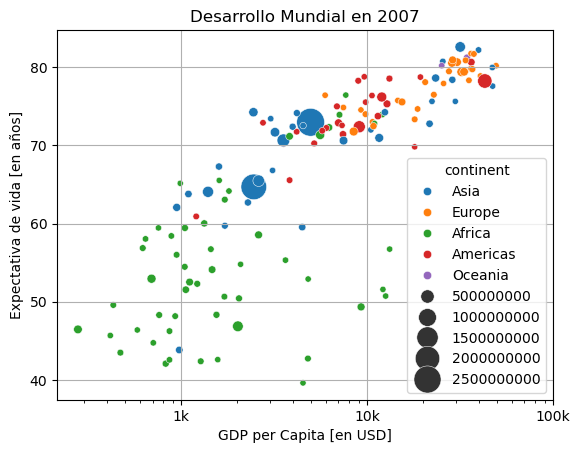

In [80]:
# Usamos scatterplot de seaborn para poder personalizar mejor el grafico

# Almacenamos la población como un array de numpy: np_pop
np_pop = np.array(datos2007["pop"])

sns.scatterplot(x = datos2007['gdpPercap'], y = datos2007['lifeExp'], hue = datos2007['continent'], size = np_pop*2, sizes=(20,400))
plt.grid(True)
plt.xscale('log')
plt.xlabel('GDP per Capita [en USD]')
plt.ylabel('Expectativa de vida [en años]')
plt.title('Desarrollo Mundial en 2007')
plt.xticks([1000, 10000, 100000],['1k', '10k', '100k'])
plt.show()

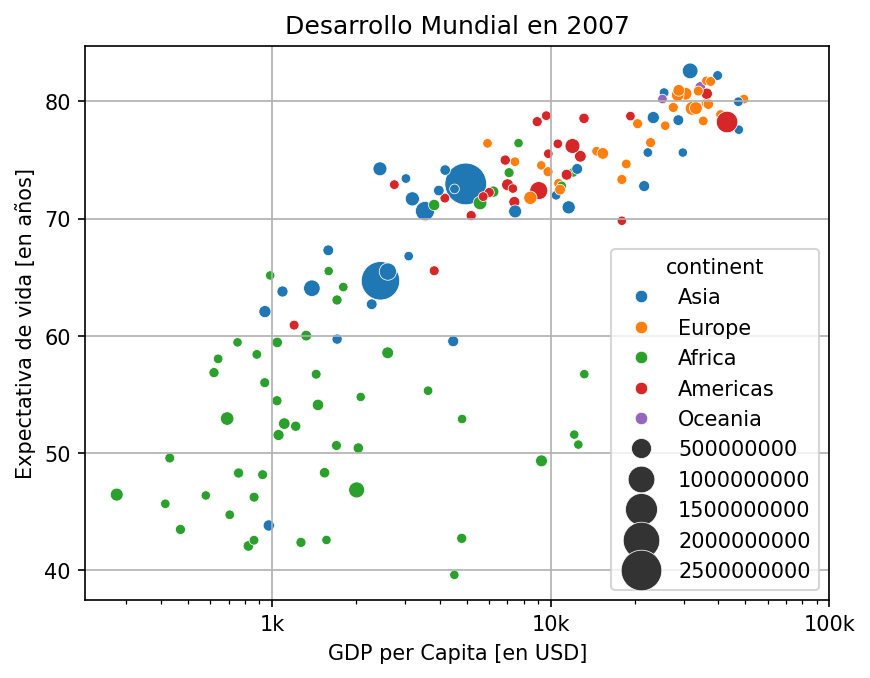

In [81]:
# Aumenta el tamaño del gráfico
plt.figure(dpi=150)

# Alcenamos la población como un array de numpy: np_pop
np_pop = np.array(datos2007["pop"])
np_pop2 = np_pop*2
# Usamos scatterplot de seaborn para poder personalizar mejor el grafico
sns.scatterplot(x = datos2007['gdpPercap'], y = datos2007['lifeExp'], hue = datos2007['continent'], size = np_pop2, sizes=(20,400))
plt.grid(True)
plt.xscale('log')
plt.xlabel('GDP per Capita [en USD]')
plt.ylabel('Expectativa de vida [en años]')
plt.title('Desarrollo Mundial en 2007')
plt.xticks([1000, 10000, 100000],['1k', '10k', '100k'])
plt.show()

## Estadística descriptiva

In [82]:
# Vamos a analizar los datos de 2007
datos2007 = gapminder[gapminder["year"]==2007]
datos2007

,country,year,pop,continent,lifeExp,gdpPercap
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
23,Albania,2007,3600523.0,Europe,76.423,5937.029526
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465
47,Angola,2007,12420476.0,Africa,42.731,4797.231267
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,2007,85262356.0,Asia,74.249,2441.576404
1667,West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
1679,Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906
1691,Zambia,2007,11746035.0,Africa,42.384,1271.211593


In [83]:
# Queremos usar los países como índices
datos2007.set_index("country")

,year,pop,continent,lifeExp,gdpPercap
country,,,,,
Afghanistan,2007,31889923.0,Asia,43.828,974.580338
Albania,2007,3600523.0,Europe,76.423,5937.029526
Algeria,2007,33333216.0,Africa,72.301,6223.367465
Angola,2007,12420476.0,Africa,42.731,4797.231267
Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...
Vietnam,2007,85262356.0,Asia,74.249,2441.576404
West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906


In [84]:
# Funcionó?
datos2007 

,country,year,pop,continent,lifeExp,gdpPercap
11,Afghanistan,2007,31889923.0,Asia,43.828,974.580338
23,Albania,2007,3600523.0,Europe,76.423,5937.029526
35,Algeria,2007,33333216.0,Africa,72.301,6223.367465
47,Angola,2007,12420476.0,Africa,42.731,4797.231267
59,Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,2007,85262356.0,Asia,74.249,2441.576404
1667,West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
1679,Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906
1691,Zambia,2007,11746035.0,Africa,42.384,1271.211593


In [85]:
# Para guardar los cambios, lo asignamos a la misma variable
datos2007 = datos2007.set_index("country")
datos2007

,year,pop,continent,lifeExp,gdpPercap
country,,,,,
Afghanistan,2007,31889923.0,Asia,43.828,974.580338
Albania,2007,3600523.0,Europe,76.423,5937.029526
Algeria,2007,33333216.0,Africa,72.301,6223.367465
Angola,2007,12420476.0,Africa,42.731,4797.231267
Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...
Vietnam,2007,85262356.0,Asia,74.249,2441.576404
West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906


In [87]:
# O usamos la opcion inplace = True
datos2007 = gapminder[gapminder["year"]==2007]
datos2007.set_index("country", inplace = True)
# datos2007

In [88]:
# O por último, hacemos todo en una sola linea (opcion recomendada)
datos2007 = gapminder[gapminder["year"]==2007].set_index("country")
datos2007

,year,pop,continent,lifeExp,gdpPercap
country,,,,,
Afghanistan,2007,31889923.0,Asia,43.828,974.580338
Albania,2007,3600523.0,Europe,76.423,5937.029526
Algeria,2007,33333216.0,Africa,72.301,6223.367465
Angola,2007,12420476.0,Africa,42.731,4797.231267
Argentina,2007,40301927.0,Americas,75.320,12779.379640
...,...,...,...,...,...
Vietnam,2007,85262356.0,Asia,74.249,2441.576404
West Bank and Gaza,2007,4018332.0,Asia,73.422,3025.349798
Yemen Rep.,2007,22211743.0,Asia,62.698,2280.769906


Mirando los datos de 2007, ¿cuál es el país con mayor expectativa de vida? ¿Cuál es el país con menor expectativa de vida?

In [91]:
print(datos2007[datos2007["lifeExp"] == datos2007["lifeExp"].max()])
print(datos2007[datos2007["lifeExp"] == datos2007["lifeExp"].min()])

         year          pop continent  lifeExp    gdpPercap
country                                                   
Japan    2007  127467972.0      Asia   82.603  31656.06806
           year        pop continent  lifeExp    gdpPercap
country                                                   
Swaziland  2007  1133066.0    Africa   39.613  4513.480643


En matemática, cuando queremos saber para qué valor se alcanza el máximo, decimos que queremos saber el "argumento" del máximo. Esta funcion suele llamarse `argmax`. Utilizar la función de numpy np.argmax para responder las preguntas.

In [93]:
datos2007.iloc[np.argmax(datos2007["lifeExp"])]

year                2007
pop          127467972.0
continent           Asia
lifeExp           82.603
gdpPercap    31656.06806
Name: Japan, dtype: object

La función de numpy devuelve la posición. Si queremos saber el índice, podemos usar el método de series de Panda idxmax().

In [94]:
datos2007["lifeExp"].idxmax()

'Japan'

### Medidas de tendencia central

Para el año 2007, calcular el valor medio y la mediana de las variables gdpPercap y lifeExp entre todos los países.
Son similares o distintas? A qué lo atribuyen? Consideran que alguna resume mejor la realidad que la otra?


In [95]:
datos2007["lifeExp"].median()

71.93549999999999

In [96]:
datos2007["lifeExp"].mean()

np.float64(67.00742253521126)

In [97]:
datos2007["gdpPercap"].median()

6124.3711084999995

In [98]:
datos2007["gdpPercap"].mean()

np.float64(11680.071819878167)

¿Es lo mismo el promedio de la expectativa de vida entre todos los países y el promedio de la expectativa de vida entre todas las personas?
¿Cuál calculamos arriba? ¿Cómo podemos calcular el otro?


In [106]:
(datos2007["lifeExp"]*datos2007["pop"]).sum() / (datos2007["pop"]).sum()

np.float64(68.91909251904043)

### Medidas de dispersión

Para el año 2007, calcular la varianza y el desvío estándar de las variables gdpPercap y lifeExp entre todos los países. ¿Cuál es más fácil de interpretar?

In [100]:
datos2007["lifeExp"].var()

145.75782404714806

In [101]:
datos2007["lifeExp"].std()

12.07302050222512